# LAB 2 - DIGITAL PHYSICS
### Felix Svedberg, Isac Östman

### Description and motivation of data generation set 

The total number of samples in the training dataset was 4765. The data generation set was created in a way to produce as many different scenarios as possible, such that our model gets to "see" as many outcomes as possible. The choice of using either uniform distribution and normal distribution was quite central in this. While we argue that uniform distribution is the best way to reduce overfit when training the model, we still wanted some of the settings to be more skewed towards a specific value. The specific trade-offs are described in more detail below, but in general, we made sure to not have a exceedingly small standard deviation in the normal distribution, as well as reasonable values for `vmin` and `vmax`. Below are more detailed descriptions of the individual settings we chose/changed. One motivation behind this thinking is also, which is the case in all of machine learning, that we do not want to "cheat" by guessing what type of data the validation data set consists of. We wanted to create something as general as possible.

__Dustpan:__ We chose normal distribution for the dustpan since we wanted the dustpan to not be too close to the broom to often, setting its mean to 0.1 length units away from its starting position, with an std of 0.2 and `vmin = 0.0`, `vmax = 0.5`.

__Small objects:__ The distribution of small objects was originally set to a uniform distribution min of 1 and a max of 6. We increased the maximum number of objects to 20 and argued that this gave the model a more general dataset to work with. The dustpan can fit more than 6 as well, and increasing the ceiling might help the model see that the number of objects captured maybe never surpasses some value $N_{max}$. The objects are distributed across a rectangle with a normal distribution in the y direction, to make objects spawn more often between the dustpan and broom, to help the model see that in general (apart from when there are large cuboids there) objects between the dustpan and broom will get captured. But the rectangle still goes outside of this area to help the model see the opposite. Finally, this rectangular distribution has a uniform distribution in the x-direction as we could not find any reason for is to be skewed in any way using a normal distribution. 

__Large Cuboid:__ The orientation of the cuboid was set such that it could be rotated at any angle in the z-direction, but none in the others. We also set the distribution of the number of objects to between 0 and 3. We argued that having as many as 20 of these long objects would not really change the outcome that much and thus decided to keep the max number low. And note that in this case the minimum number of objects is 0, since these objects often could result in zero captured objects. 

### Notes on the model training
The model uses a transformer architecture and some of the tuning parameters were changed. The tuning parameters were mostly altered by trial and error, seeing wether changing them increased the validation accuracy or not. The final model achieved a validation accuracy of around 94%. The hyperparameters were:

`action_dim = 1`

`token_dim = 9`

`d_model = 64`

`feedforward_dim = 64`

`num_layers = 3`

`num_heads = 1`

`use_class_embeddings = True`

`embedding_dim = 8`

`num_classes = len(CLASS_TO_IDX)`
        

### Additional comments
When running simulations with cylinders, they were often restarted because the cylinders started rolling away and never settled. 

### Evalute our trained predictor model on three selected cases

In [91]:

import sys
import os

agx_root = r"C:\Users\Isac\AppData\Local\Algoryx\AGX-2.41.3.0"

agx_python = r"C:\Users\Isac\AppData\Local\Algoryx\AGX-2.41.3.0\data\python\modules"

sys.path.insert(0, agx_python)

sys.path.append(os.path.join(agx_root, "bin", "x64", "agxpy"))

os.add_dll_directory(os.path.join(agx_root, "bin", "x64"))
os.add_dll_directory(os.path.join(agx_root, "bin"))

import agx
import agxPythonModules

import matplotlib.pyplot as plt
import numpy as np
import torch
import yaml
from model_training.architectures import ARCHITECTURES
from model_training.eval_utils import (ModelInterface, draw_scene,
                                       optimize_action)
from utils import unpack_npz_sample

### Load our trained model from disk

In [92]:
model_dir = "trained_models"  # Change this to your actual model path
model_path = os.path.join(model_dir, "model.pt")
metadata_path = os.path.join(model_dir, "metadata.yaml")

# Load metadata
with open(metadata_path, "r") as f:
    metadata = yaml.safe_load(f)

# Extract model kwargs from metadata
model_kwargs = metadata["model_kwargs"]

# Instantiate model
model = ARCHITECTURES[metadata["architecture"]](**model_kwargs)

# Load model state dict
state_dict = torch.load(model_path, map_location=torch.device("cpu"))
success = model.load_state_dict(state_dict)
print("Model loaded successfully:", success)

# Wrap the model in the ModelInterface for more convenient usage
model = ModelInterface(model)

Model loaded successfully: <All keys matched successfully>


## CASE 1
<p align="left">
    <img src="runs/case_study_1/frame_0.png" width="700">
</p>

Sanity check your model by evaluating on the simplest episode possible

**What to report:**
- Nothing from Case 1, this is just to get you started

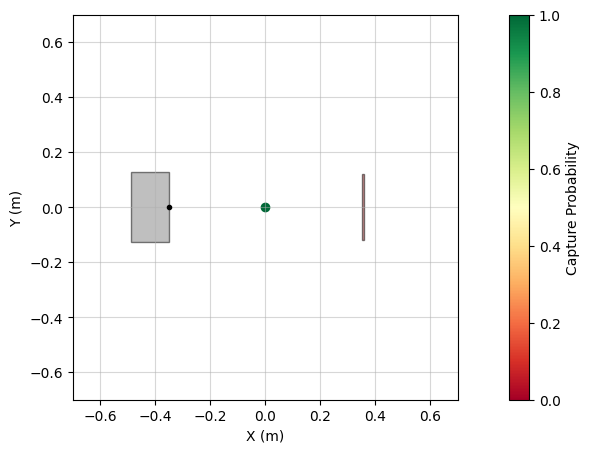

In [93]:
# Load the episode data
episode_data_path = os.path.join("runs", "case_study_1", "episode_0.npz")
episode_data = dict(np.load(episode_data_path, allow_pickle=True))
episode_data = unpack_npz_sample(episode_data)

# <episode_data> contains an action just like all other episode files, but we only want
# the object data for model evaluation
object_affines = episode_data["objects"]["affine4x4"]
class_names = episode_data["objects"]["object_class"]

# action4d is a 4-tuple (x, y, theta, d)
action = torch.tensor([-.35, 0.0, 0.0, 0.7],
                      device=model.device, dtype=torch.float32)
capture_probabilities = model.predict_from_action(
    action4d=action,
    object_affines=object_affines,
    class_names=class_names,
)

# Plot this action and the predicted outcome
fig, ax = plt.subplots(1, 2, figsize=(6, 5), gridspec_kw={"width_ratios": [1, 0.05]})
ax[0].set_xlim(-0.7, 0.7)
ax[0].set_ylim(-0.7, 0.7)
ax[0].grid(alpha=0.5)
ax[0].set_aspect('equal')

# Green/Red colormap for Success/Fail is intuitive but not colorblind-friendly
cmap = "RdYlGn"  # Feel free to change if you want

draw_scene(
    ax=ax[0],
    action4d=action.cpu().numpy(),
    object_affines=object_affines,
    class_names=class_names,
    capture_probabilities=[capture_probabilities.cpu().numpy()],
    cmap=cmap
)

ax[0].set_xlabel("X (m)")
ax[0].set_ylabel("Y (m)")

plt.colorbar(
    plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=0, vmax=1)),
    cax=ax[1],
    label="Capture Probability"
)

### Sweep model through the action space

Evaluate you model along the line $a = [-0.35, y, 0.0, 0.7],\: y\in[-0.4, 0.4]$ and plot the expected number of captured objects

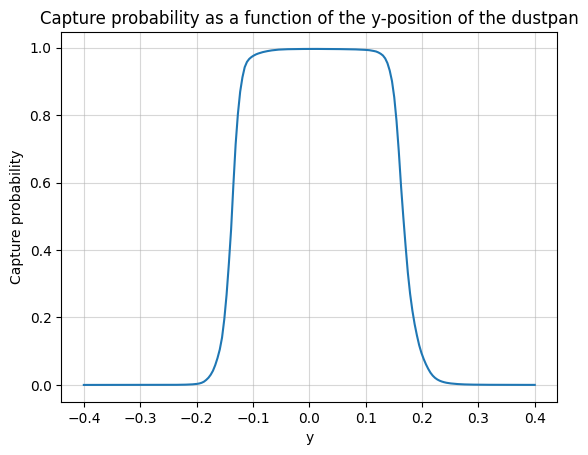

In [94]:
y_vals = np.linspace(-0.4, 0.4, 200)
n_captured = []

for y in y_vals:
    action = torch.tensor([-.35, y, 0.0, 0.7], device=model.device, dtype=torch.float32)
    capture_probabilities = model.predict_from_action(
        action4d=action,
		object_affines=object_affines,
    	class_names=class_names,
    )
    # N_hat is the sum of the capture probabilities
    n_captured.append(capture_probabilities.sum().item())

# Plot the expected number of captured objects as a function of the y
# coordinate of the action

plt.figure()
plt.plot(y_vals,n_captured)
plt.ylabel('Capture probability')
plt.xlabel('y')
plt.title('Capture probability as a function of the y-position of the dustpan')
plt.grid(alpha=0.5)
plt.show()



## Case 2
<p align="left">
    <img src="runs/case_study_2/frame_0.png" width="800">
</p>

### Task 2.1
Repeat the same sweep as you did for Case 1 and plot the results

**What to report:**
- A plot showing $\hat{N}_\mathrm{in}$ as a function of $y$. Interpret your results.

In [95]:
# Load the episode data
episode_data_path = os.path.join("runs", "case_study_2", "episode_0.npz")
episode_data = dict(np.load(episode_data_path, allow_pickle=True))
episode_data = unpack_npz_sample(episode_data)

# <episode_data> contains an action just like all other episode files, but we only want
# the object data for model evaluation
object_affines = episode_data["objects"]["affine4x4"]
class_names = episode_data["objects"]["object_class"]

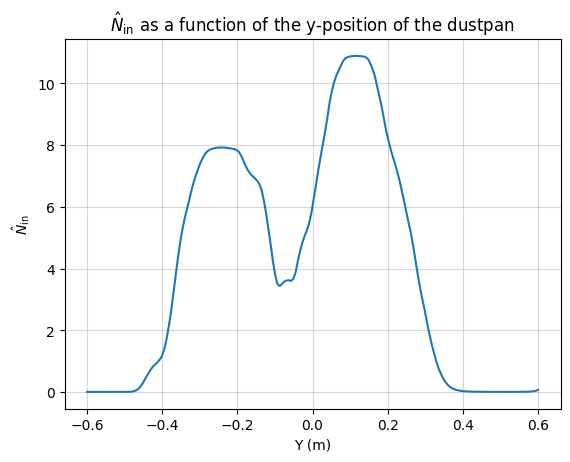

In [96]:
y_vals = np.linspace(-0.6,0.6,200)
N_in = []

for y in y_vals:
    action = torch.tensor([-.35, y, 0.0, 0.7], device=model.device, dtype=torch.float32)
    capture_probabilities = model.predict_from_action(
        action4d=action,
    object_affines=object_affines,
    class_names=class_names,
    )
    # N_hat is the sum of the capture probabilities
    N_in.append(capture_probabilities.sum().item())
    
plt.figure()
plt.plot(y_vals,N_in)
plt.ylabel(r'$\hat{N}_\mathrm{in}$')
plt.xlabel('Y (m)')
plt.title(r'$\hat{N}_\mathrm{in}$ as a function of the y-position of the dustpan')
plt.grid(alpha=0.5)
plt.show()
    


### __ANSWER 2.1:__

Reasonable results, moving the scoop upwards places the group of 11 objects between the scoop and blade, so around 10 objects are captured. Moving downwards places the group of less than 10 objects between the tools, so we capture less than 10. Outside of these ranges the amount captured is close to zero. When y is between these two groups the model predicts much less, but still more than 1.

### Task 2.2
Make another sweep, this time along the circle defined by
$$
    x^2 + y^2 = 0.9^2
$$
remember to adjust the scoop's orientation $\psi$ accordingly

**What to report:**
- A plot of $\hat{N}_\mathrm{in}$ as a function of $\theta$, where $\theta$ parametrizes the circle.
- Is the model $\pi$-periodic? Do we expect it to be?

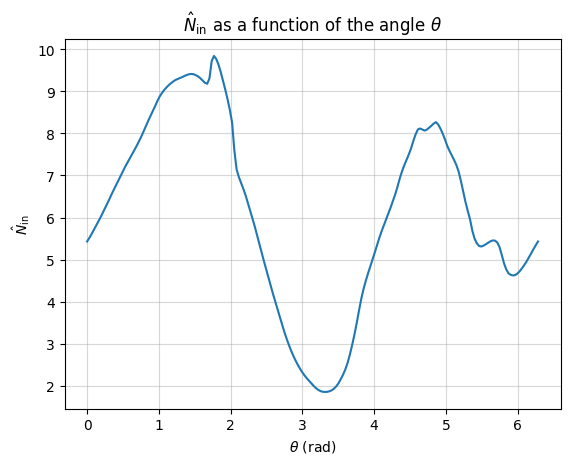

In [97]:
angles = np.linspace(0.0,2.*3.141592,200)
N_in2 = []
radius = 0.9

for theta in angles:
    # Use sin and cosine to position along circle of radius 0.9
    x = radius*np.cos(theta)
    y = radius*np.sin(theta)
    phi = theta + 3.141592 # plus pi since we want it to point in the exact opposite direction
    
    action = torch.tensor([x, y, phi, radius], device=model.device, dtype=torch.float32)
    capture_probabilities = model.predict_from_action(
        action4d=action,
    object_affines=object_affines,
    class_names=class_names,
    )
    # N_hat is the sum of the capture probabilities
    N_in2.append(capture_probabilities.sum().item())
    
plt.figure()
plt.plot(angles,N_in2)
plt.ylabel(r'$\hat{N}_\mathrm{in}$')
plt.xlabel(r'$\theta$ (rad)')
plt.title(r'$\hat{N}_\mathrm{in}$ as a function of the angle $\theta$')
plt.grid(alpha=0.5)
plt.show()

### __ANSWER 2.2:__ 

The dustpan starts at the position which would correspond to the right border of the figure given of the setup, and from the plot we see that the output is approximately periodic. While we get two peaks at $\pi/2$ and $3\pi/2$ radians, the peak at $\pi /2$ radians predicts around 9 or 10 captured objects, while the peak at 0 radians predicts around 8 captured objects. This is a reasonable result since we set the position of the dustpan at the edge of the circle, while the broom is at the origin. This means that depending on which pile of objects is between the dustpan and broom, we get different numbers of captured objects (The piles contain different amounts of objects). The reason as to why the peaks are so wide is that the model still can capture some of the objects on the edges of the piles when the setup is at an angle.

### Task 2.3
Let's return to the straight line sweep from Task 2.1. Use the provided function 'optimize_action' to try to find the optimal value of $y$ along this line. Does the optimal value match your previous results?

Note that 'optimize_action' will try to optimize all four action parameters simultaneously. We
can however zero out the gradient in the directions we don't want to optimize over using the gradient_mask. [0, 1, 0, 0] means we only optimize the second action parameter, the y coordinate. 

Play around with different choices of initial guess and optimizer parameters (learning rate, and number of steps). Does the gradient ascent optimizer always converge on the same action? If not, why?

**What to report:**
- Nothing, but this will help you solve Task 3.2

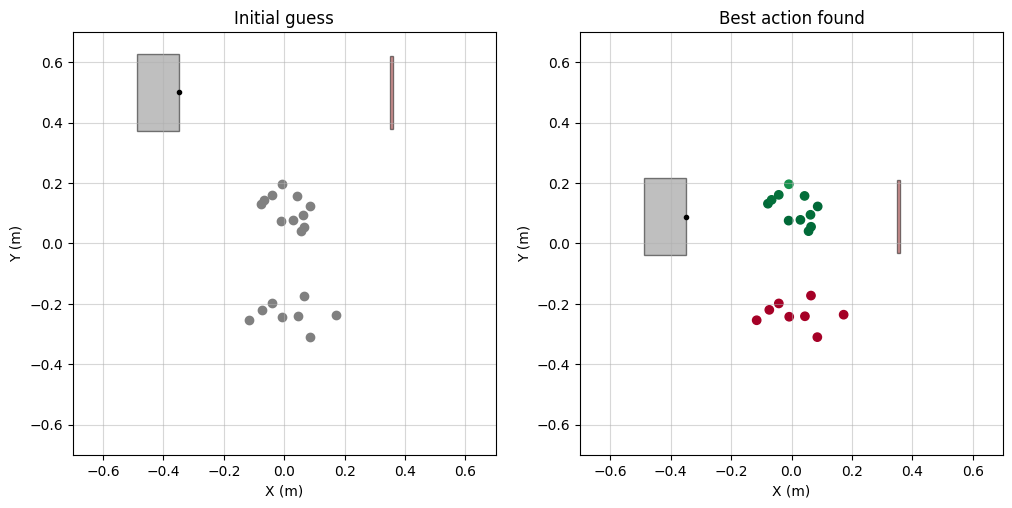

In [98]:


# Initial guess for the optimizer
init_action = torch.tensor([-0.35, 0.5, 0.0, 0.7],
                           dtype=torch.float32,
                           device=model.device)

# Plot the initial position
fig, ax = plt.subplots(1, 2, figsize=(12, 10))
ax[0].set_xlim(-0.7, 0.7)
ax[0].set_ylim(-0.7, 0.7)
ax[0].grid(alpha=0.5)
ax[0].set_aspect('equal')
ax[0].set_xlabel("X (m)")
ax[0].set_ylabel("Y (m)")
ax[0].set_title('Initial guess')

# Plot it in the same style as in case 1 so it is easy to see
draw_scene(
    ax=ax[0],
    action4d=init_action.cpu().numpy(),
    object_affines=object_affines,
    class_names=class_names,
    capture_probabilities=None, 
    cmap=cmap
)

# This tells PyTorch that we want to compute gradients with respect to the action
init_action.requires_grad = True

# Mask to zero out gradients for the dimensions of the action we don't want to optimize
gradient_mask = torch.tensor([0.0, 1.0, 0.0, 0.0], device=model.device)

# Optimize the action using the model's gradients
action_opt, obj = optimize_action(
    model=model,
    data=episode_data,
    gradient_mask=gradient_mask,
    init_action=init_action,  # Change this if you want
    steps=500, # Change this
    lr=0.05  # Change this
    )

probabilities = model.predict_from_action(
    action4d=action_opt,
    object_affines=episode_data["objects"]["affine4x4"],
    class_names=episode_data["objects"]["object_class"],
)



ax[1].set_xlim(-0.7, 0.7)
ax[1].set_ylim(-0.7, 0.7)
ax[1].grid(alpha=0.5)
ax[1].set_aspect('equal')
ax[1].set_xlabel("X (m)")
ax[1].set_ylabel("Y (m)")
ax[1].set_title('Best action found')

# Plot it in the same style as in case 1 so it is easy to see
draw_scene(
    ax=ax[1],
    action4d=action_opt.cpu().numpy(),
    object_affines=object_affines,
    class_names=class_names,
    capture_probabilities=probabilities, 
    cmap=cmap
)

## Case 3

<p align="left">
    <img src="runs/case_study_3/frame_0.png" width="800">
</p>

In [99]:
# Load the episode data
episode_data_path = os.path.join("runs", "case_study_3", "episode_0.npz")
episode_data = dict(np.load(episode_data_path, allow_pickle=True))
episode_data = unpack_npz_sample(episode_data)

# <episode_data> contains an action just like all other episode files, but we only want
# the object data for model evaluation
object_affines = episode_data["objects"]["affine4x4"]
class_names = episode_data["objects"]["object_class"]

### Task 3.1
Make a sweep along the circle defined by
$$
    x^2 + y^2 = 0.9^2
$$

**What to report:**
- A plot of $\hat{N}$ as a function of $\theta$, where $\theta$ paramaterizes the circle.
- Is the function's periodicity the same as in Task 2.2? Do we expect it to be?

__ANSWER:__


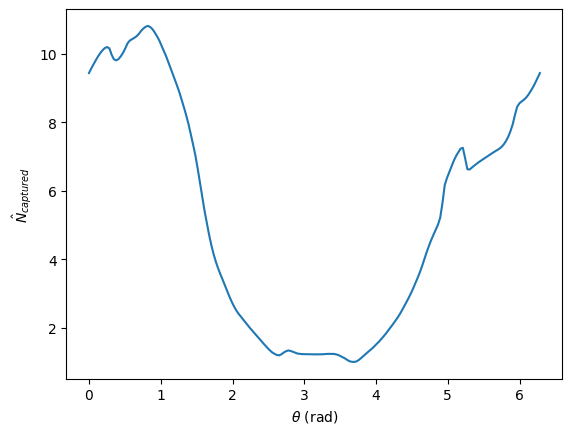

In [100]:
angles2 = np.linspace(0,2*3.141592,200)
N_in3 = []
radius = 0.9

for theta in angles2:
    # Use sin and cosine to position along circle of radius 0.9
    x = radius*np.cos(theta)
    y = radius*np.sin(theta)
    phi = theta + 3.141592
    
    action = torch.tensor([x, y, phi, radius], device=model.device, dtype=torch.float32)
    capture_probabilities = model.predict_from_action(
        action4d=action,
    object_affines=object_affines,
    class_names=class_names,
    )
    # N_hat is the sum of the capture probabilities
    N_in3.append(capture_probabilities.sum().item())
    
plt.figure()
plt.plot(angles2,N_in3)
plt.ylabel(r"$\hat{N}_{captured}$")
plt.xlabel(r"$\theta$ (rad)")
plt.show()

### __ANSWER 3.1:__

We do not see the same plot as in 2.2, which is expected. Here we start the dustpan in the right of the picture, which in the graph corresponds to theta = 0. Here we see a much larger peak, which of course comes from the large pile, which is not obscured by the large cuboid. When we come around to $\pi$ radians we come across the single cube positioned by the large cuboid. Since all other objects are obscured by the large cuboid, the model predicts around 1 captured objects which means that only the small solitary cube is captured.  

### Task 3.2
As we saw in Task 2.3, the learned function can be expected to have several local maxima. Knowing this it can be a good idea do multiple optimization runs with random inital guesses for the action $a$ and simply keep the best one.

**Your task:**

Complete the code to find the optimal values of $x, y$, and $\psi$ while keeping $d=0.9$.

**What to report:**
- A plot showing the optimal action according to your model
- Does the model's best action makes sense? If not, discuss why not
- State one or two aspects of the scoop planning problem that the current model *does not* take into account.


New best found:
tensor([ 0.2503,  0.2929, -2.2428,  0.9000])
New best found:
tensor([ 0.1671, -0.1931,  1.7951,  0.9000])
New best found:
tensor([ 0.1662, -0.1896,  1.7956,  0.9000])


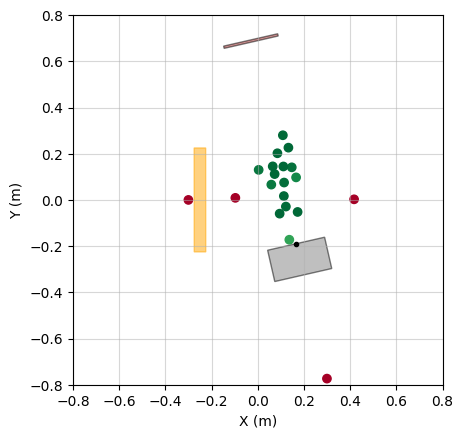

In [101]:
def multi_start_optimization(
        num_restarts: int = 20,
        **opt_kwargs):
    # Init optimization variables
    best_action = None
    best_objective = -float("inf")

    gradient_mask = torch.tensor([1.0, 1.0, 1.0, 0.0])

    for i in range(num_restarts):
        
        # Assign a random starting point 
        x_rand = np.random.uniform(-1.0,1.0)
        y_rand = np.random.uniform(-1.0,1.0)
        phi_rand = np.random.uniform(-3.141592,3.141592)

        # Random initialization of the action
        init_action = torch.tensor([x_rand, y_rand, phi_rand, 0.9])

        action_opt, obj = optimize_action(init_action=init_action,
                                          gradient_mask=gradient_mask,
                                          **opt_kwargs)
        # Check wether we found a better action
        if obj > best_objective:
            best_objective = obj
            best_action = action_opt
            print('New best found:')
            print(best_action)

    return best_action, best_objective

best_action, best_objective = multi_start_optimization(
    num_restarts=20,
    model=model,
    data=episode_data,
    steps=250,
    )

y_probs = model.predict_from_action(
    action4d=best_action,
    object_affines=episode_data["objects"]["affine4x4"],
    class_names=episode_data["objects"]["object_class"],
)

fig, ax = plt.subplots()
ax.set_xlim(-0.8, 0.8)
ax.set_ylim(-0.8, 0.8)
ax.grid(alpha=0.5)
ax.set_aspect('equal')
ax.set_xlabel("X (m)")
ax.set_ylabel("Y (m)")

draw_scene(
    ax,
    action4d=best_action.detach().numpy(),
    object_affines=episode_data["objects"]["affine4x4"],
    class_names=episode_data["objects"]["object_class"],
    capture_probabilities=y_probs.detach().numpy()
)



### __ANSWER 3.2:__

The results show that the best action is the one above, when the dustpan is situated such that its movement is aligned with the long axis of the elongated shape of the large pile in the setup. This is a reasonable result, with one other possible option couldve been the mirrored case, with the dustpan being above the pile (in relation to the figure), and the broom below. 

In its current form, one limitation with the model formulation is that 